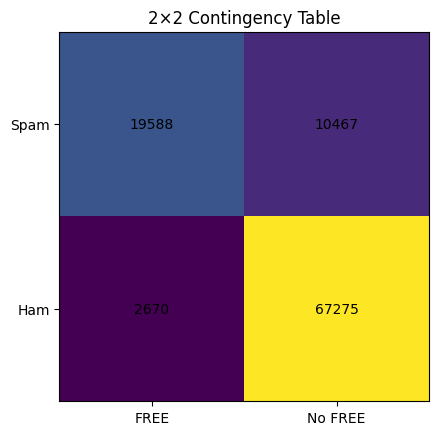

Empirical Results:
P(FREE) = 0.22258
P(spam | FREE) = 0.88004
P(ham | FREE) = 0.11996

Bayes Theorem Results:
P(FREE) = 0.22300
P(spam | FREE) = 0.87444
P(ham | FREE) = 0.12556


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Parameters
n = 100_000
p_spam = 0.30
p_free_given_spam = 0.65
p_free_given_ham = 0.04


spam_status = np.random.choice([1, 0], size=n, p=[p_spam, 1 - p_spam])


contains_free = np.zeros(n, dtype=int)


spam_indices = spam_status == 1
ham_indices = spam_status == 0

contains_free[spam_indices] = (np.random.rand(np.sum(spam_indices)) < p_free_given_spam)
contains_free[ham_indices] = (np.random.rand(np.sum(ham_indices)) < p_free_given_ham)

free_mask = contains_free == 1

P_free = np.mean(contains_free)
P_spam_given_free = np.sum((spam_status == 1) & free_mask) / np.sum(free_mask)
P_ham_given_free = np.sum((spam_status == 0) & free_mask) / np.sum(free_mask)


P_ham = 1 - p_spam

P_free_bayes = (p_free_given_spam * p_spam +
                p_free_given_ham * P_ham)

P_spam_given_free_bayes = (p_free_given_spam * p_spam) / P_free_bayes
P_ham_given_free_bayes = (p_free_given_ham * P_ham) / P_free_bayes


table = np.array([
    [np.sum((spam_status == 1) & (contains_free == 1)),
     np.sum((spam_status == 1) & (contains_free == 0))],
    [np.sum((spam_status == 0) & (contains_free == 1)),
     np.sum((spam_status == 0) & (contains_free == 0))]
])


plt.figure()
plt.imshow(table)

for i in range(2):
    for j in range(2):
        plt.text(j, i, table[i, j], ha='center', va='center')

plt.xticks([0, 1], ['FREE', 'No FREE'])
plt.yticks([0, 1], ['Spam', 'Ham'])
plt.title('2×2 Contingency Table')

plt.show()


print("Empirical Results:")
print(f"P(FREE) = {P_free:.5f}")
print(f"P(spam | FREE) = {P_spam_given_free:.5f}")
print(f"P(ham | FREE) = {P_ham_given_free:.5f}")

print("\nBayes Theorem Results:")
print(f"P(FREE) = {P_free_bayes:.5f}")
print(f"P(spam | FREE) = {P_spam_given_free_bayes:.5f}")
print(f"P(ham | FREE) = {P_ham_given_free_bayes:.5f}")